# Molecular prediction over the whole axis (axis-200-900)

Head metrics over all classes of this axis for training pixels, withheld test pixels, the rare-class test extension and the held-out images, to measure how the molecular prediction generalizes to new pixels and to new images.

## Introduction

The head predicts, per pixel, the probability that each train-observed molecule is annotated. Metrics are
computed per class and aggregated (macro and micro) in two ranking populations that treat unlabelled entries
differently.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* The head was trained with the variational PU loss: annotations are positive, missing annotations are unlabelled.
  `annotation_retrieval` therefore treats unlabelled entries as negatives and underestimates precision when
  annotations are incomplete; `operational_pn` removes entries with signal but no annotation.
* Threshold metrics use $\hat Y \ge 0.5$; VPU logits are treated as 0.5-anchored as in the earlier head analyses.
* Evaluations: `train`, `test`, `test_extended`, `test_combined` (test and extension together, the main per-class
  estimate for rare classes) and `heldout_image`.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Ranking populations: `annotation_retrieval` (every available entry; annotated = positive, everything else
  negative) and `operational_pn` (only evidence positives P and operational negatives N; unlabelled entries with
  signal at the ion's bins, U, are excluded). Evidence rule: peak above 1.19 % of the spectrum maximum within
  +/- 1 bin.
* AP: average precision per class; macro = mean over eligible classes (at least one positive and one negative in
  the evaluated population and training support); micro = one ranking over all eligible entries.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "prediction_global"
AXIS = "axis-200-900"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

EVALUATIONS = ['train', 'test', 'test_combined', 'heldout_image']
EVALUATION_COLORS = {name: POPULATION_COLORS[name] for name in EVALUATIONS}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'micro_prevalence', 'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1',
                'hamming_loss']


def metric_table(frame, index, columns, column_order):
    """Mean +/- SD over repetitions of every metric of a long table (`metric`, `value`)."""
    long = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).copy()
    long['metric'] = pd.Categorical(long.metric, categories=[name for name in METRIC_ORDER if name in set(long.metric)], ordered=True)
    grouped = long.groupby([*index, 'metric', columns], observed=True).value
    cells = grouped.mean().map('{:.4f}'.format) + ' +/- ' + grouped.std().map('{:.4f}'.format)
    shown = cells.unstack(columns)
    return shown[[name for name in column_order if name in shown.columns]]


def metric_columns_table(frame, index):
    """Mean +/- SD over repetitions of every metric column of a wide table."""
    columns = [name for name in METRIC_ORDER if name in frame.columns]
    grouped = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).groupby(index)[columns]
    return grouped.mean().round(4).astype(str) + ' +/- ' + grouped.std().round(4).astype(str)

prediction = table('prediction')

Analysis: prediction_global | axis: axis-200-900 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 200-900 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`ranking_tables` (the same implementation as the earlier head analyses) is evaluated in the `inference` level on
every population, on test and extension together, and on every held-out image separately.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis prediction_global > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis         repetition model_id                                                                                                                                                      
axis-200-900 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6970  0.4851       3.2834                   0.8835          0.9449        3.0           False
             1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6899  0.4772       2.9758                   0.8751          1.0732        4.2           False
             2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6990  0.5055       3.1069                   0.8918          0.9337        1.4            True
             3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6947  0.4789       3.1123                   0.9003          0.9509        3.2           False
             4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6957  0.4872       3.1081                   0.8833          0.9554        3.2           False

### Remarks

- Representative model: repetition 2 (mean rank 1.4 of 5): best macro AP (0.699), F1 (0.506) and spectral angle (0.934); repetition 1 has the lowest $W_1$ (2.98) but the worst angle and AP, so no repetition wins every metric.

### Notes

## Aggregate prediction metrics per evaluation population

### Methodology

#### Theoretical

Macro AP weights every class equally, micro AP weights every entry equally; ROC AUC is threshold free;
micro precision, recall and F1 are evaluated at $\hat Y \ge 0.5$.

#### Implementation

`prediction` rows with scope `train_supported` (all classes observed in training).

#### Figure descriptions

One panel per metric; x = evaluation population, colour = ranking population, one point per repetition, bar =
mean. The table lists the complete metric set (mean +/- SD over repetitions) per ranking population and
evaluation population: macro and micro AP, ROC AUC, AP above prevalence, micro prevalence, macro and micro
precision, recall and F1 at 0.5 and the Hamming loss.

evaluation                                                train               test      test_extended      test_combined      heldout_image
population           metric                                                                                                                
annotation_retrieval average_precision        0.6764 +/- 0.0034  0.6953 +/- 0.0034  0.7084 +/- 0.0041  0.7088 +/- 0.0033  0.3557 +/- 0.0075
                     micro_average_precision  0.8873 +/- 0.0094  0.8868 +/- 0.0096  0.8892 +/- 0.0056  0.8828 +/- 0.0088  0.5924 +/- 0.0097
                     roc_auc                  0.9906 +/- 0.0002  0.9890 +/- 0.0005  0.9712 +/- 0.0004  0.9866 +/- 0.0003  0.6966 +/- 0.0084
                     micro_roc_auc            0.9953 +/- 0.0002  0.9953 +/- 0.0002  0.9866 +/- 0.0006  0.9938 +/- 0.0003  0.8096 +/- 0.0038
                     ap_above_prevalence      0.6241 +/- 0.0034  0.6428 +/- 0.0034  0.6195 +/- 0.0041  0.6503 +/- 0.0033  0.1217 +/- 0.0075
                     micro_prevalence         0.0523 +/- 0.0000  0.0525 +/- 0.0000  0.0889 +/- 0.0000  0.0585 +/- 0.0000  0.2339 +/- 0.0000
                     precision                0.5824 +/- 0.0213  0.5551 +/- 0.0181  0.5355 +/- 0.0217  0.5739 +/- 0.0236  0.3375 +/- 0.0349
                     recall                   0.4986 +/- 0.0160  0.4981 +/- 0.0158  0.4277 +/- 0.0145  0.4971 +/- 0.0164  0.1338 +/- 0.0138
                     f1                       0.4873 +/- 0.0109  0.4868 +/- 0.0112  0.4376 +/- 0.0121  0.4908 +/- 0.0121  0.1401 +/- 0.0153
                     micro_precision          0.8405 +/- 0.0060  0.8402 +/- 0.0059  0.8657 +/- 0.0193  0.8469 +/- 0.0090  0.6637 +/- 0.0064
                     micro_recall             0.8616 +/- 0.0057  0.8600 +/- 0.0060  0.6905 +/- 0.0135  0.8063 +/- 0.0072  0.3063 +/- 0.0202
                     micro_f1                 0.8509 +/- 0.0025  0.8500 +/- 0.0028  0.7680 +/- 0.0104  0.8261 +/- 0.0048  0.4189 +/- 0.0200
                     hamming_loss             0.0158 +/- 0.0003  0.0159 +/- 0.0003  0.0371 +/- 0.0017  0.0199 +/- 0.0006  0.1986 +/- 0.0032
operational_pn       average_precision        0.8562 +/- 0.0023  0.8603 +/- 0.0040  0.8574 +/- 0.0034  0.8786 +/- 0.0022  0.7688 +/- 0.0030
                     micro_average_precision  0.9865 +/- 0.0052  0.9862 +/- 0.0055  0.9575 +/- 0.0014  0.9796 +/- 0.0041  0.9233 +/- 0.0010
                     roc_auc                  0.9952 +/- 0.0004  0.9943 +/- 0.0005  0.9815 +/- 0.0004  0.9922 +/- 0.0003  0.8537 +/- 0.0179
                     micro_roc_auc            0.9986 +/- 0.0002  0.9986 +/- 0.0002  0.9915 +/- 0.0003  0.9973 +/- 0.0002  0.9189 +/- 0.0037
                     ap_above_prevalence      0.7201 +/- 0.0023  0.7247 +/- 0.0040  0.6699 +/- 0.0034  0.7341 +/- 0.0022  0.2385 +/- 0.0030
                     micro_prevalence         0.1252 +/- 0.0000  0.1249 +/- 0.0000  0.1557 +/- 0.0000  0.1283 +/- 0.0000  0.4849 +/- 0.0000
                     precision                0.6747 +/- 0.0263  0.6297 +/- 0.0215  0.5984 +/- 0.0236  0.6585 +/- 0.0254  0.5932 +/- 0.0530
                     recall                   0.4986 +/- 0.0160  0.4981 +/- 0.0158  0.4302 +/- 0.0138  0.4971 +/- 0.0164  0.1421 +/- 0.0147
                     f1                       0.5308 +/- 0.0151  0.5275 +/- 0.0148  0.4660 +/- 0.0149  0.5319 +/- 0.0161  0.1789 +/- 0.0186
                     micro_precision          0.9830 +/- 0.0014  0.9819 +/- 0.0015  0.9623 +/- 0.0014  0.9767 +/- 0.0012  0.9868 +/- 0.0091
                     micro_recall             0.8616 +/- 0.0057  0.8600 +/- 0.0060  0.6907 +/- 0.0139  0.8063 +/- 0.0072  0.3082 +/- 0.0203
                     micro_f1                 0.9183 +/- 0.0030  0.9169 +/- 0.0033  0.8041 +/- 0.0090  0.8834 +/- 0.0042  0.4694 +/- 0.0236
                     hamming_loss             0.0192 +/- 0.0006  0.0195 +/- 0.0007  0.0524 +/- 0.0020  0.0273 +/- 0.0009  0.3375 +/- 0.0095

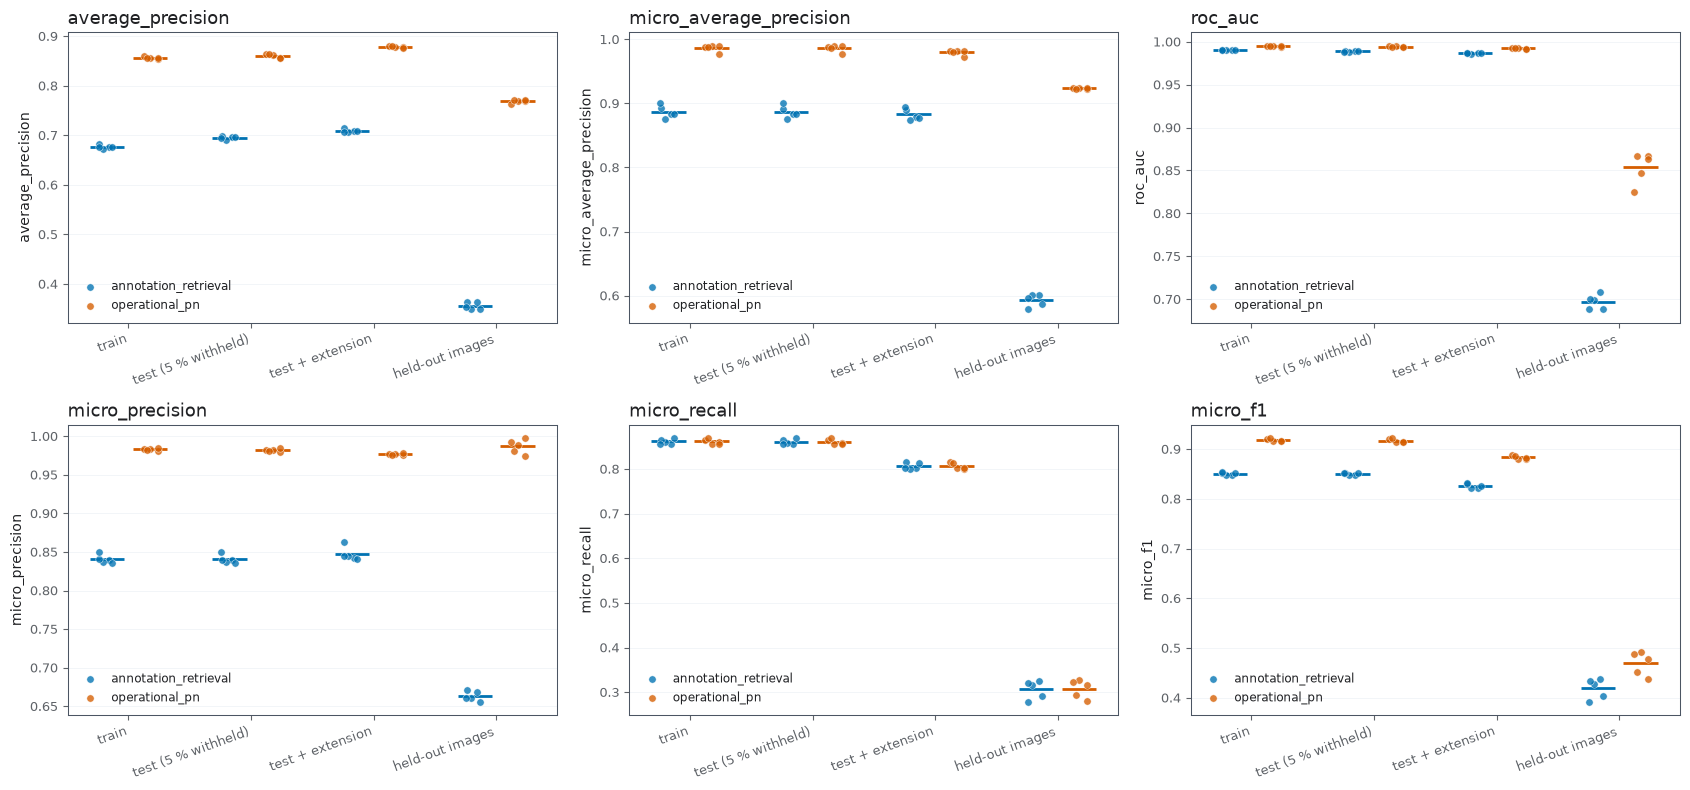

In [4]:
metrics = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_precision', 'micro_recall', 'micro_f1']
shown = prediction[(prediction.scope == 'train_supported') & prediction.metric.isin(metrics)]
figure, axes = plt.subplots(2, 3, figsize=(17, 8), dpi=theme.figure_dpi)
for ax, metric in zip(axes.flat, metrics):
    figures.repetition_points(shown[shown.metric == metric], value='value', group='evaluation', hue='population', order=EVALUATIONS, hue_order=['annotation_retrieval', 'operational_pn'], colors={'annotation_retrieval': theme.model_palette[0], 'operational_pn': theme.model_palette[1]}, ylabel=metric, title=metric, ax=ax, theme=theme)
figure.tight_layout()
full = prediction[prediction.scope == 'train_supported']
display(metric_table(full, ['population'], 'evaluation', ['train', 'test', 'test_extended', 'test_combined', 'heldout_image']))

### Remarks

- Test (annotation retrieval, repetition means): macro AP 0.695, micro AP 0.887, macro / micro ROC AUC 0.989 / 0.995, micro precision / recall 0.84 / 0.86, Hamming loss 0.016; train is equal (no overfitting to training pixels).
- Held-out images pooled: macro AP 0.356, micro AP 0.592, micro ROC AUC 0.81, micro precision / recall 0.66 / 0.31, Hamming loss 0.20. The micro prevalence rises from 0.05 to 0.23: annotated ions cover large parts of the held-out images.
- Operational P/N on held-out images: micro precision 0.99 with micro recall 0.31: what the head predicts at 0.5 is almost always an evidence positive, but most positives stay below 0.5.

### Notes

## Generalization gaps of the head

### Methodology

#### Theoretical

Per repetition: test minus train (new pixels of seen images), held-out minus test (new images) and test+extension
minus test (effect of adding rare-class support).

#### Implementation

`gaps` holds the metric per evaluation and the differences.

#### Figure descriptions

No figure; means and SDs over repetitions, every metric.

In [5]:
gaps = table('gaps')
display(mean_sd(gaps[gaps.scope == 'train_supported'].drop(columns='axis'), ['population', 'metric'], ['test_minus_train', 'heldout_minus_test', 'combined_minus_test']).round(4))

mean                                                     std                                    
quantity                                     combined_minus_test heldout_minus_test test_minus_train combined_minus_test heldout_minus_test test_minus_train
population           metric                                                                                                                                 
annotation_retrieval ap_above_prevalence                  0.0075            -0.5210           0.0187              0.0021             0.0055           0.0015
                     average_precision                    0.0135            -0.3396           0.0188              0.0021             0.0055           0.0015
                     f1                                   0.0040            -0.3467          -0.0005              0.0026             0.0148           0.0026
                     hamming_loss                         0.0039             0.1826           0.0001              0.0003             0.0034           0.0000
                     micro_average_precision             -0.0040            -0.2944          -0.0005              0.0025             0.0180           0.0005
                     micro_f1                            -0.0239            -0.4310          -0.0009              0.0024             0.0220           0.0005
                     micro_precision                      0.0067            -0.1765          -0.0002              0.0038             0.0083           0.0003
                     micro_prevalence                     0.0060             0.1814           0.0002              0.0000             0.0000           0.0000
                     micro_recall                        -0.0537            -0.5537          -0.0016              0.0038             0.0216           0.0008
                     micro_roc_auc                       -0.0015            -0.1857          -0.0001              0.0001             0.0040           0.0000
                     precision                            0.0188            -0.2176          -0.0273              0.0068             0.0297           0.0048
                     recall                              -0.0010            -0.3643          -0.0005              0.0042             0.0142           0.0037
                     roc_auc                             -0.0024            -0.2924          -0.0016              0.0002             0.0082           0.0003
operational_pn       ap_above_prevalence                  0.0094            -0.4862           0.0046              0.0022             0.0058           0.0030
                     average_precision                    0.0183            -0.0915           0.0041              0.0022             0.0058           0.0030
                     f1                                   0.0045            -0.3486          -0.0034              0.0042             0.0169           0.0037
                     hamming_loss                         0.0079             0.3180           0.0003              0.0004             0.0096           0.0001
                     micro_average_precision             -0.0066            -0.0629          -0.0004              0.0014             0.0046           0.0003
                     micro_f1                            -0.0335            -0.4475          -0.0014              0.0020             0.0243           0.0005
                     micro_precision                     -0.0051             0.0049          -0.0011              0.0006             0.0077           0.0002
                     micro_prevalence                     0.0034             0.3600          -0.0003              0.0000             0.0000           0.0000
                     micro_recall                        -0.0537            -0.5518          -0.0016              0.0038             0.0217           0.0008
                     micro_roc_auc                       -0.0012            -0.0796          -0.0001              0.0001             0.

### Remarks

### Notes

## Prediction metrics per held-out image

### Methodology

#### Theoretical

Each held-out image carries its own annotations (7-16 molecules); metrics are computed per image to show
whether the average hides an image-specific failure.

#### Implementation

`image_prediction` rows (group = image).

#### Figure descriptions

x = held-out image, colour = ranking population, one point per repetition; panels = macro AP, micro AP, ROC AUC. The table gives the complete metric set per image (mean +/- SD).

group                                        2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s
population           metric                                                                                
annotation_retrieval average_precision          0.6224 +/- 0.0114    0.6061 +/- 0.0025    0.5208 +/- 0.0111
                     micro_average_precision    0.7434 +/- 0.0104    0.8351 +/- 0.0064    0.8358 +/- 0.0086
                     roc_auc                    0.7284 +/- 0.0121    0.7767 +/- 0.0074    0.7182 +/- 0.0130
                     micro_roc_auc              0.7520 +/- 0.0190    0.8888 +/- 0.0017    0.9066 +/- 0.0061
                     ap_above_prevalence        0.1718 +/- 0.0114    0.1606 +/- 0.0025    0.1366 +/- 0.0111
                     micro_prevalence           0.4506 +/- 0.0000    0.4455 +/- 0.0000    0.3842 +/- 0.0000
                     precision                  0.5124 +/- 0.0897    0.3891 +/- 0.0687    0.4274 +/- 0.0473
                     recall                     0.1743 +/- 0.0220    0.1187 +/- 0.0054    0.1767 +/- 0.0151
                     f1                         0.1974 +/- 0.0295    0.1204 +/- 0.0104    0.2080 +/- 0.0180
                     micro_precision            0.8626 +/- 0.0201    0.8926 +/- 0.0024    0.9115 +/- 0.0258
                     micro_recall               0.3186 +/- 0.0314    0.2333 +/- 0.0079    0.3640 +/- 0.0278
                     micro_f1                   0.4642 +/- 0.0317    0.3699 +/- 0.0101    0.5197 +/- 0.0287
                     hamming_loss               0.3303 +/- 0.0087    0.3540 +/- 0.0033    0.2580 +/- 0.0105
operational_pn       average_precision          0.9145 +/- 0.0110    0.8998 +/- 0.0088    0.7854 +/- 0.0080
                     micro_average_precision    0.9286 +/- 0.0077    0.9556 +/- 0.0062    0.9593 +/- 0.0054
                     roc_auc                    0.8855 +/- 0.0355    0.9289 +/- 0.0194    0.7972 +/- 0.0127
                     micro_roc_auc              0.8394 +/- 0.0245    0.9398 +/- 0.0063    0.9457 +/- 0.0046
                     ap_above_prevalence        0.3012 +/- 0.0110    0.3076 +/- 0.0088    0.1777 +/- 0.0080
                     micro_prevalence           0.6718 +/- 0.0000    0.6604 +/- 0.0000    0.6285 +/- 0.0000
                     precision                  0.5974 +/- 0.0910    0.4564 +/- 0.0640    0.5531 +/- 0.0643
                     recall                     0.1743 +/- 0.0220    0.0109 +/- 0.0073    0.1914 +/- 0.0163
                     f1                         0.2096 +/- 0.0324    0.0208 +/- 0.0136    0.2306 +/- 0.0200
                     micro_precision            0.9975 +/- 0.0026    0.9970 +/- 0.0025    0.9726 +/- 0.0195
                     micro_recall               0.3186 +/- 0.0314    0.0172 +/- 0.0109    0.3687 +/- 0.0282
                     micro_f1                   0.4822 +/- 0.0366    0.0336 +/- 0.0210    0.5342 +/- 0.0296
                     hamming_loss               0.4584 +/- 0.0209    0.6491 +/- 0.0072    0.4034 +/- 0.0176

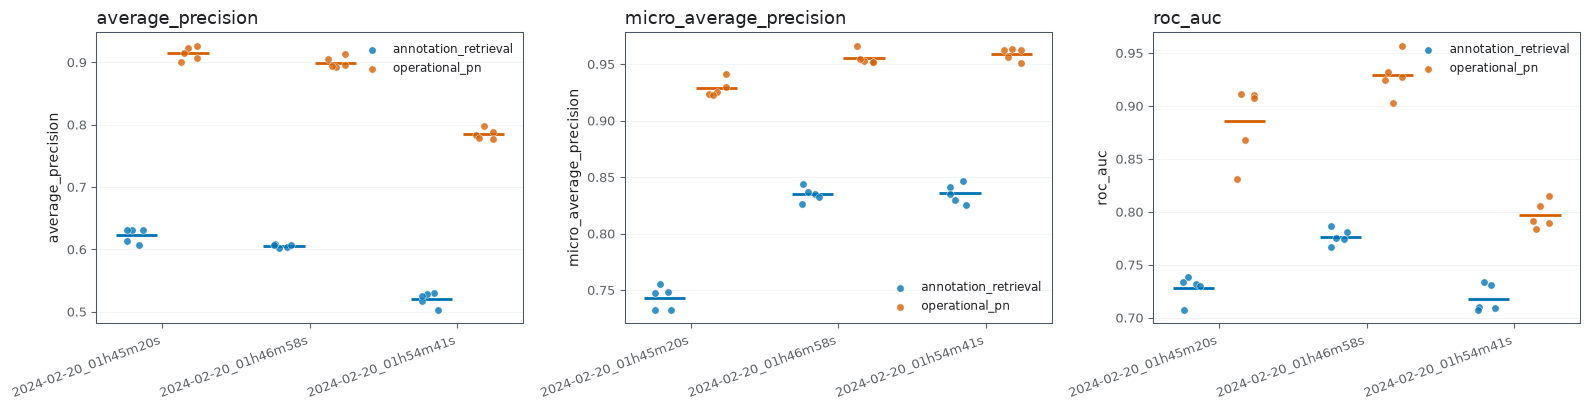

In [6]:
images = table('image_prediction')
images = images[images.scope == 'train_supported']
figure, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=theme.figure_dpi)
for ax, metric in zip(axes, ['average_precision', 'micro_average_precision', 'roc_auc']):
    figures.repetition_points(images[images.metric == metric], value='value', group='group', hue='population', order=DATASETS, hue_order=['annotation_retrieval', 'operational_pn'], colors={'annotation_retrieval': theme.model_palette[0], 'operational_pn': theme.model_palette[1]}, ylabel=metric, title=metric, ax=ax, theme=theme)
figure.tight_layout()
display(metric_table(images, ['population'], 'group', DATASETS))

### Remarks

- Per image: macro AP 0.52-0.62, micro AP 0.74-0.84, micro recall 0.23-0.36, Hamming 0.26-0.35.
- Per-image values are clearly higher than the pooled held-out values (macro AP 0.36): in the pooled evaluation a class annotated in one image counts every pixel of the other images as negative, although METASPACE may simply not have annotated it there. Per-image metrics are the fairer measure of generalization to a new image.

### Notes

## Per-class average precision

### Methodology

#### Theoretical

The distribution of per-class AP shows whether the macro mean reflects most classes or is carried by a few;
AP against training support shows how much a class needs to be learned.

#### Implementation

`per_class` rows of eligible classes, ranking population `annotation_retrieval`; repetition means for the scatter.

#### Figure descriptions

First figure: x = evaluation population, violin = per-class AP pooled over repetitions, diamonds = macro AP per
repetition. Second: x = training positives (log), y = repetition-mean AP (test + extension), colour = support
frequency bucket. Third: the same for every held-out image separately (one panel per image, AP of the classes
annotated in that image), to show how the dependence on training support differs between new images.

,classes,median_ap
group,,
2024-02-20_01h45m20s,7,0.7665
2024-02-20_01h46m58s,9,0.8370
2024-02-20_01h54m41s,13,0.5418


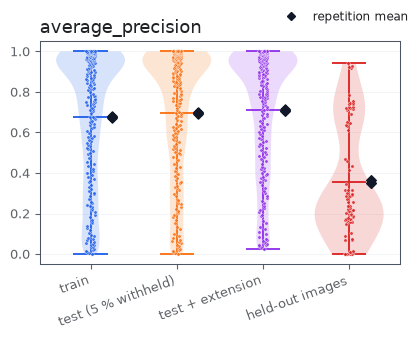

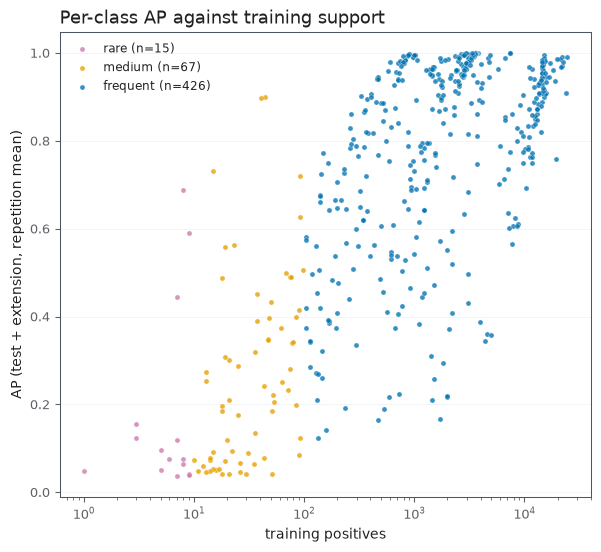

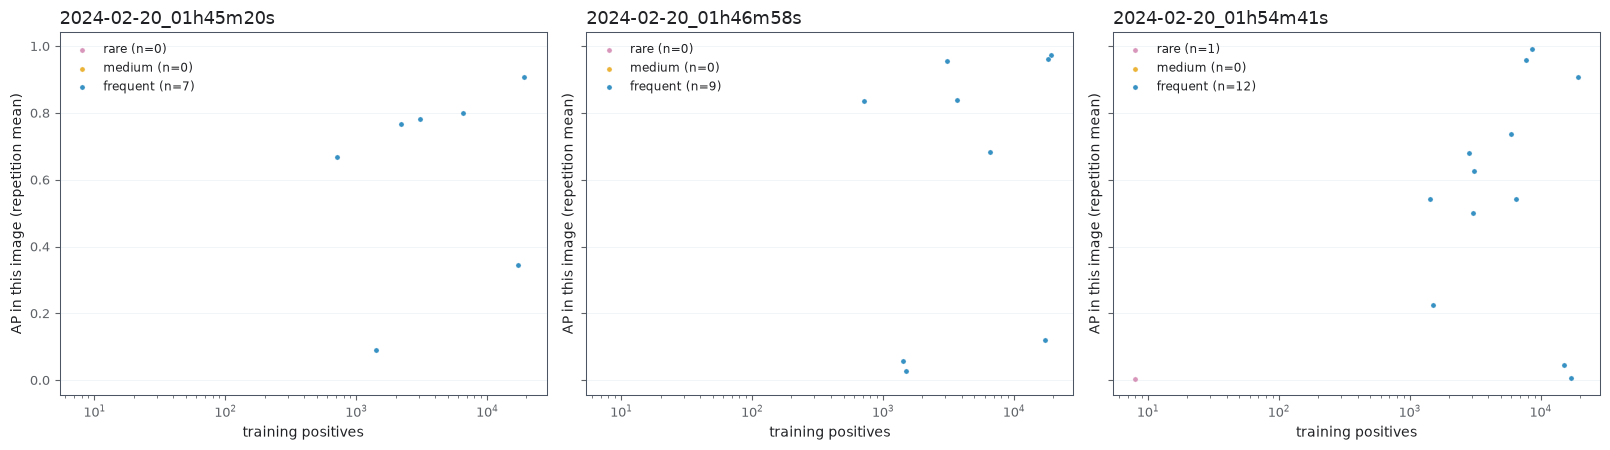

In [7]:
per_class = table('per_class')
image_classes = per_class[(per_class.group != 'all') & per_class.eligible.astype(bool) & (per_class.population == 'annotation_retrieval')]
per_class = per_class[per_class.group == 'all']
eligible = per_class[per_class.eligible.astype(bool) & (per_class.population == 'annotation_retrieval')].rename(columns={'population': 'ranking', 'evaluation': 'population'})
means = eligible.groupby(['repetition', 'population']).average_precision.mean().reset_index(name='mean').assign(metric='average_precision')
figures.population_distributions(eligible, means, ['average_precision'], EVALUATIONS, columns=1, theme=theme);
classes = eligible[eligible.population == 'test_combined'].groupby(['class_name', 'frequency'], as_index=False).agg(train_positives=('train_positives', 'first'), average_precision=('average_precision', 'mean'))
figures.paired_scatter(classes, x='train_positives', y='average_precision', hue='frequency', hue_order=['rare', 'medium', 'frequent'], xlabel='training positives', ylabel='AP (test + extension, repetition mean)', title='Per-class AP against training support', diagonal=False, colors={'rare': theme.model_palette[3], 'medium': theme.model_palette[4], 'frequent': theme.model_palette[0]}, theme=theme).axes[0].set_xscale('log')
per_image = image_classes.groupby(['group', 'class_name', 'frequency'], as_index=False).agg(train_positives=('train_positives', 'first'), average_precision=('average_precision', 'mean'))
figure, axes = plt.subplots(1, len(DATASETS), figsize=(5.4 * len(DATASETS), 4.6), dpi=theme.figure_dpi, sharex=True, sharey=True)
for ax, dataset in zip(axes, DATASETS):
    figures.paired_scatter(per_image[per_image.group == dataset], x='train_positives', y='average_precision', hue='frequency', hue_order=['rare', 'medium', 'frequent'], xlabel='training positives', ylabel='AP in this image (repetition mean)', title=dataset, diagonal=False, colors={'rare': theme.model_palette[3], 'medium': theme.model_palette[4], 'frequent': theme.model_palette[0]}, ax=ax, theme=theme)
    ax.set_xscale('log')
figure.tight_layout()
display(per_image.groupby('group').agg(classes=('class_name', 'size'), median_ap=('average_precision', 'median')))

### Remarks

- Per image 7 / 9 / 13 eligible classes with median AP 0.77 / 0.84 / 0.54; the Spearman correlation between training positives and AP is 0.57 / 0.58 / 0.30.
- Every image has 1-3 classes with AP < 0.2, and all classes with AP > 0.8 have at least 717 training positives: good support is necessary but not sufficient on a new image.

### Notes

## Score distributions by evidence state

### Methodology

#### Theoretical

A useful head scores evidence positives above unlabelled entries and those above operational negatives.
Quantiles of $\hat Y$ per state show the separation and the calibration level.

#### Implementation

`score_diagnostics` holds quantiles of the positive probability per state, evaluation and repetition.

#### Figure descriptions

No figure; repetition-mean median and 90 % quantile of the probability per state and evaluation.

In [8]:
scores = table('score_diagnostics')
scores = scores[(scores.group == 'all') & (scores.quantity == 'positive_probability') & scores['quantile'].isin([0.5, 0.9])]
display(scores.pivot_table(index=['state', 'quantile'], columns='evaluation', values='value', aggfunc='mean')[[column for column in EVALUATIONS + ['test_extended'] if column in set(scores.evaluation)]])

,evaluation,train,test,test_combined,heldout_image,test_extended
state,quantile,,,,,
N,0.5,4.9330e-08,4.7327e-08,9.7346e-08,5.6537e-08,7.8763e-07
P,0.5,9.5556e-01,9.5566e-01,9.2598e-01,2.0477e-01,8.0831e-01
U,0.5,7.8388e-08,7.6591e-08,1.3686e-07,1.8297e-07,2.2526e-06


### Remarks

- Median probability of evidence positives falls from 0.96 (test) to 0.21 (held-out images); unlabelled and negative entries stay at 0.

### Notes

## Results / Summary

### LLM

- **Observed:** on new pixels of seen images the head is as good as on training pixels across the complete metric set (micro AP 0.89, Hamming 0.016).
- **Observed:** on new images the ranking survives partially (per-image micro AP 0.74-0.84, macro AP 0.52-0.62) but the 0.5 threshold does not: micro recall 0.23-0.36 at micro precision 0.86-0.91.
- **Interpretation:** the head transfers its ranking to new images but its probabilities shift down; a threshold calibrated on the target image, or per-image evaluation, is needed. Pooled held-out metrics understate the ranking quality because annotations are incomplete across images.

### Person